# Normalizing flow leave-one-galaxy-out cross-validation

Trains on 4/5 galaxies, evaluates on the held-out 5th.
Reports R² and NLL per fold, plus a sampled scatter plot for each held-out galaxy.

In [1]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parents[1]) if Path.cwd().name == "normflow" else str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from sfemulator.normflow.model import train_flow, predict_mean, predict_nll, sample
from sfemulator.data.loader import (
    load_all_galaxies, prepare_log_data, GALAXIES,
    SURFDENS_TO_MSUN_PC2, SFR_SURFDENS_TO_MSUN_YR_KPC2,
)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [2]:
SNAP_DIR = Path("../../snapshots")
data = load_all_galaxies(SNAP_DIR)
galaxy_names = list(GALAXIES.keys())
print(galaxy_names)

NGC300: 31 snapshots, 40556 star-forming pixels
ETG-vlM: 31 snapshots, 12532 star-forming pixels
ETG-lowM: 31 snapshots, 28816 star-forming pixels
ETG-medM: 30 snapshots, 19053 star-forming pixels
ETG-hiM: 22 snapshots, 31052 star-forming pixels
['NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM']


In [3]:
# Leave-one-galaxy-out: train on 4, evaluate on held-out 1
results = {}

for held_out in galaxy_names:
    train_names = [n for n in galaxy_names if n != held_out]
    print(f"\n=== Fold: held out {held_out}, training on {train_names} ===")

    # Prepare training data
    X_train_log, y_train_log, _ = prepare_log_data(data, train_names)
    x_scaler = StandardScaler().fit(X_train_log)
    y_scaler = StandardScaler().fit(y_train_log.reshape(-1, 1))
    X_scaled = x_scaler.transform(X_train_log).astype(np.float32)
    y_scaled = y_scaler.transform(y_train_log.reshape(-1, 1)).ravel().astype(np.float32)
    y_mean = y_scaler.mean_[0]
    y_std = y_scaler.scale_[0]
    print(f"  Training samples: {len(y_scaled)}")

    # Train
    model, losses = train_flow(
        X_scaled, y_scaled,
        n_layers=8, n_hidden=64, n_bins=16, tail_bound=5.0,
        lr=1e-3, n_epochs=20, batch_size=2048, device=device,
    )

    # Evaluate on held-out galaxy
    ctx_test, sfr_sd_test = data[held_out]
    log_ctx_test = np.log10(ctx_test)
    log_sfr_test = np.log10(sfr_sd_test)
    finite_test = np.all(np.isfinite(log_ctx_test), axis=1) & np.isfinite(log_sfr_test)

    X_test_scaled = x_scaler.transform(log_ctx_test[finite_test]).astype(np.float32)
    X_test_t = torch.tensor(X_test_scaled).to(device)
    y_test_true = log_sfr_test[finite_test]
    y_test_scaled = ((y_test_true - y_mean) / y_std).astype(np.float32)
    y_test_t = torch.tensor(y_test_scaled).to(device)

    # Flow R² (predict in standardized space, unstandardize to CGS log)
    y_pred_scaled = predict_mean(model, X_test_t)
    y_pred_cgs = y_pred_scaled * y_std + y_mean
    r2 = r2_score(y_test_true, y_pred_cgs)

    # Flow NLL (adjust for Jacobian of standardization)
    nll = predict_nll(model, X_test_t, y_test_t) + np.log(y_std)

    # KS98 baseline on held-out galaxy
    log_gas_msun = np.log10(ctx_test[finite_test, 0] * SURFDENS_TO_MSUN_PC2)
    y_pred_ks = np.log10(2.5e-4) + 1.4 * log_gas_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    r2_ks = r2_score(y_test_true, y_pred_ks)
    # KS98 NLL with variance from training set
    ks_train_pred = np.log10(2.5e-4) + 1.4 * np.log10(
        np.concatenate([data[n][0] for n in train_names])[prepare_log_data(data, train_names)[2], 0] * SURFDENS_TO_MSUN_PC2
    ) - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    ks_var = np.var(y_train_log - ks_train_pred)
    nll_ks = 0.5 * np.log(2 * np.pi * ks_var) + 0.5 * np.mean((y_test_true - y_pred_ks)**2) / ks_var

    results[held_out] = {
        "model": model, "x_scaler": x_scaler, "y_mean": y_mean, "y_std": y_std,
        "losses": losses,
        "r2": r2, "nll": nll, "r2_ks": r2_ks, "nll_ks": nll_ks,
        "finite_test": finite_test,
    }
    print(f"  {held_out}: R²={r2:.4f} (KS98={r2_ks:.4f}), NLL={nll:.4f} (KS98={nll_ks:.4f})")


=== Fold: held out NGC300, training on ['ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM'] ===
  Training samples: 91445


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_23879/805884230.py:27: RuntimeWarning: divide by zero encountered in log10
  log_ctx_test = np.log10(ctx_test)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_23879/805884230.py:27: RuntimeWarning: invalid value encountered in log10
  log_ctx_test = np.log10(ctx_test)


  NGC300: R²=-0.9428 (KS98=-0.1681), NLL=13.3886 (KS98=2.6682)

=== Fold: held out ETG-vlM, training on ['NGC300', 'ETG-lowM', 'ETG-medM', 'ETG-hiM'] ===
  Training samples: 118183


/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)
/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  ETG-vlM: R²=0.3074 (KS98=-0.0102), NLL=1.5102 (KS98=2.0703)

=== Fold: held out ETG-lowM, training on ['NGC300', 'ETG-vlM', 'ETG-medM', 'ETG-hiM'] ===
  Training samples: 101899


/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  ETG-lowM: R²=0.2812 (KS98=-0.0084), NLL=1.7438 (KS98=2.4205)

=== Fold: held out ETG-medM, training on ['NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-hiM'] ===
  Training samples: 111662


/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  ETG-medM: R²=0.6461 (KS98=-0.7564), NLL=1.2511 (KS98=1.9087)

=== Fold: held out ETG-hiM, training on ['NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM'] ===
  Training samples: 99671
  ETG-hiM: R²=0.4316 (KS98=0.0109), NLL=1.6294 (KS98=2.0090)


/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/Users/smrj3/GalactISM/sfemulator/data/loader.py:78: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


In [4]:
# Summary table
print(f"{'Held-out':<12} {'R² (Flow)':>10} {'R² (KS98)':>10} {'NLL (Flow)':>11} {'NLL (KS98)':>11}")
print("-" * 58)
for name in galaxy_names:
    r = results[name]
    print(f"{name:<12} {r['r2']:>10.4f} {r['r2_ks']:>10.4f} {r['nll']:>11.4f} {r['nll_ks']:>11.4f}")

Held-out      R² (Flow)  R² (KS98)  NLL (Flow)  NLL (KS98)
----------------------------------------------------------
NGC300          -0.9428    -0.1681     13.3886      2.6682
ETG-vlM          0.3074    -0.0102      1.5102      2.0703
ETG-lowM         0.2812    -0.0084      1.7438      2.4205
ETG-medM         0.6461    -0.7564      1.2511      1.9087
ETG-hiM          0.4316     0.0109      1.6294      2.0090


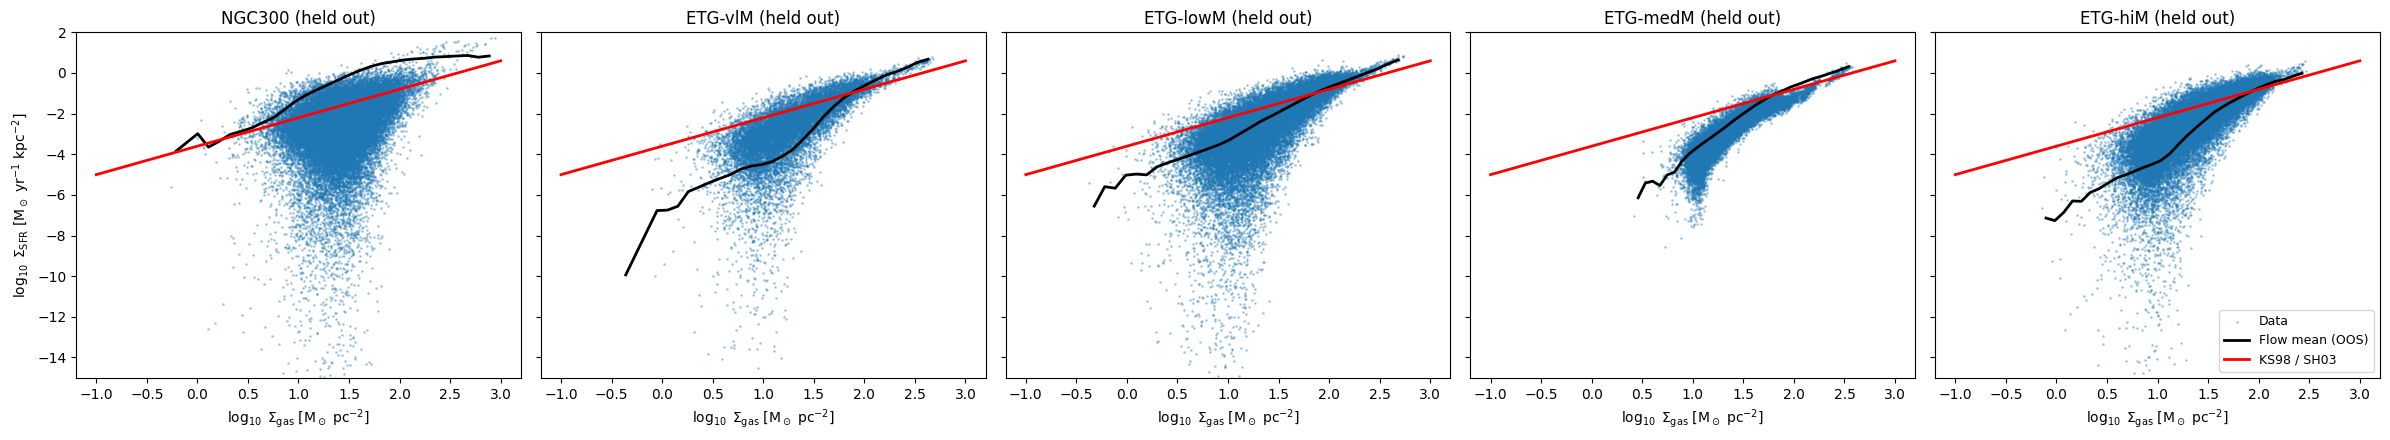

In [5]:
# KS relation with flow mean line, per held-out galaxy
sig_gas_ks = np.logspace(-1, 3, 200)
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for ax, name in zip(axes, galaxy_names):
    r = results[name]
    ctx_test, sfr_sd_test = data[name]
    log_gas = np.log10(ctx_test[:, 0] * SURFDENS_TO_MSUN_PC2)
    log_sfr_actual = np.log10(sfr_sd_test * SFR_SURFDENS_TO_MSUN_YR_KPC2)
    ax.scatter(log_gas, log_sfr_actual, s=1, alpha=0.3, label="Data")

    # Flow mean prediction (unstandardize)
    finite_test = r["finite_test"]
    X_test_scaled = r["x_scaler"].transform(np.log10(ctx_test[finite_test])).astype(np.float32)
    X_test_t = torch.tensor(X_test_scaled).to(device)
    log_sfr_pred = predict_mean(r["model"], X_test_t) * r["y_std"] + r["y_mean"] + np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)

    # Binned mean
    log_gas_v = log_gas[finite_test]
    bin_edges = np.linspace(log_gas_v.min(), log_gas_v.max(), 31)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_means = np.full(30, np.nan)
    for i in range(30):
        in_bin = (log_gas_v >= bin_edges[i]) & (log_gas_v < bin_edges[i + 1])
        if in_bin.sum() > 0:
            bin_means[i] = np.mean(log_sfr_pred[in_bin])
    ok = np.isfinite(bin_means)
    ax.plot(bin_centers[ok], bin_means[ok], "k-", lw=2, label="Flow mean (OOS)")

    ax.plot(np.log10(sig_gas_ks), np.log10(sig_sfr_ks), "r-", lw=2, label="KS98 / SH03")
    ax.set_title(f"{name} (held out)")
    ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylim([-15., 2.])
axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
axes[-1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

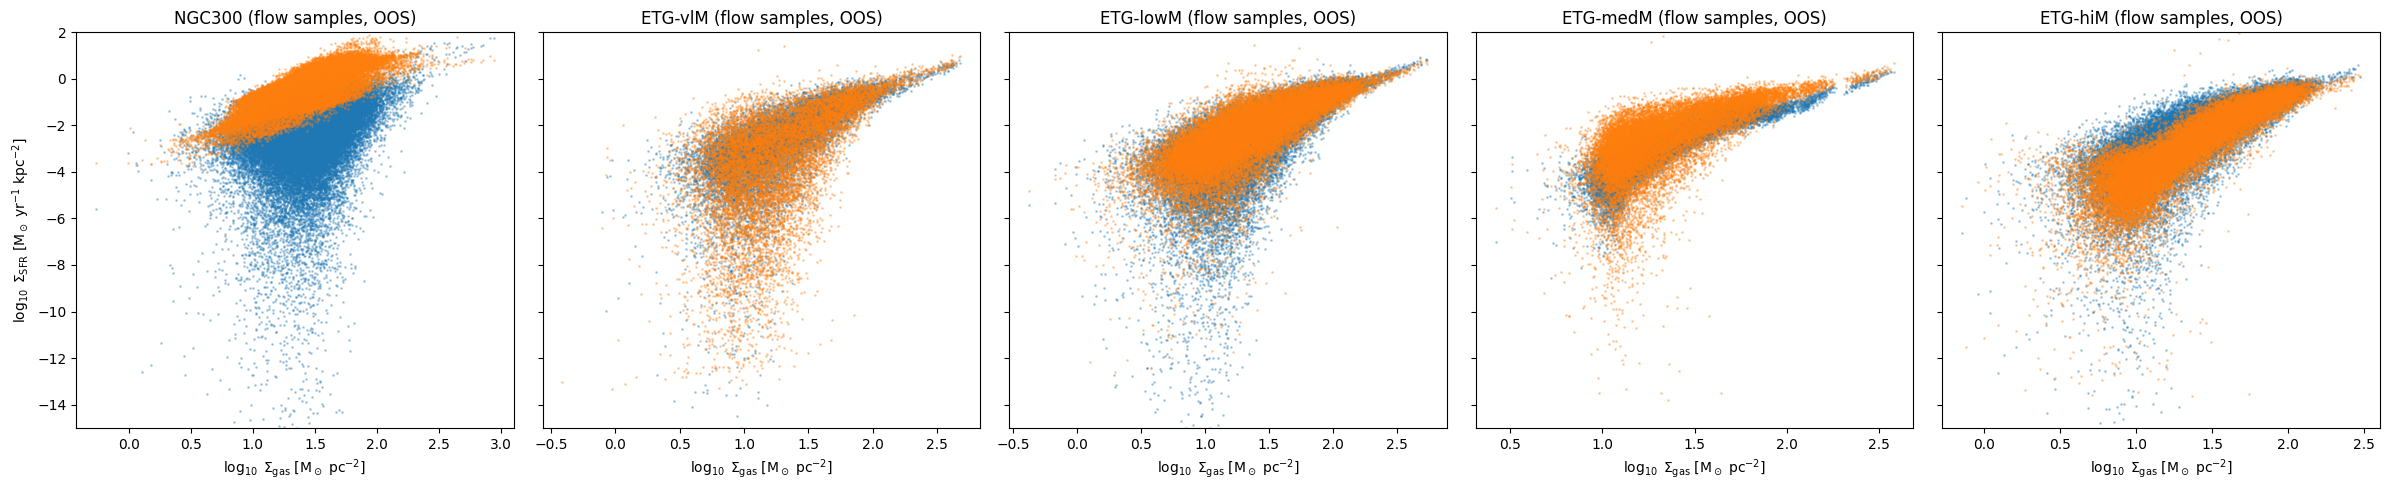

In [6]:
# Sampled KS relation per held-out galaxy
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

for col, name in enumerate(galaxy_names):
    r = results[name]
    ctx_test, sfr_sd_test = data[name]
    log_gas = np.log10(ctx_test[:, 0] * SURFDENS_TO_MSUN_PC2)

    finite_test = r["finite_test"]
    X_test_scaled = r["x_scaler"].transform(np.log10(ctx_test[finite_test])).astype(np.float32)
    X_test_t = torch.tensor(X_test_scaled).to(device)
    log_sfr_sampled = sample(r["model"], X_test_t) * r["y_std"] + r["y_mean"] + np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)

    ctx_test, sfr_sd_test = data[name]
    log_gas = np.log10(ctx_test[:, 0] * SURFDENS_TO_MSUN_PC2)
    log_sfr_actual = np.log10(sfr_sd_test * SFR_SURFDENS_TO_MSUN_YR_KPC2)
    axes[col].scatter(log_gas, log_sfr_actual, s=1, alpha=0.3, label="Data")

    axes[col].scatter(log_gas[finite_test], log_sfr_sampled, s=1, alpha=0.3)
    axes[col].set_ylim([-15., 2.])
    axes[col].set_title(f"{name} (flow samples, OOS)")
    axes[col].set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")

plt.tight_layout()
plt.show()